In [1]:
# Step 1: Import Necessary Libraries
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn import image, plotting, masking, datasets
from nilearn.input_data import NiftiMasker
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score 
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

## Reading the ROIs **(MEAN)** to perform the experiments.

In [2]:
#### 1. Loading the Inferior Frontal Gyrus dataset in np format.
cmd1 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/control_mean_pars_triangularis.npz")
ndmd1 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/non_dyslexic_mean_pars_triangularis.npz")
control_mean_data1 = cmd1["control_mean_data1"]
non_dyslexic_mean_data1=ndmd1["non_dyslexic_mean_data1"]
cmd2 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/control_mean_pars_opercularis.npz")
ndmd2 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/non_dyslexic_mean_pars_opercularis.npz")
control_mean_data2 = cmd2["control_mean_data2"]
non_dyslexic_mean_data2=ndmd2["non_dyslexic_mean_data2"]
####
#### 2. Loading the Superior Temporal Gyrus dataset in np format.
cmd3 = np.load("../../Data_Mask-ROI/2-Superior_Temporal_Gyrus/control_mean_anterior_division.npz")
ndmd3 = np.load("../../Data_Mask-ROI/2-Superior_Temporal_Gyrus/non_dyslexic_mean_anterior_division.npz")
control_mean_data3 = cmd3["control_mean_data1"]
non_dyslexic_mean_data3=ndmd3["non_dyslexic_mean_data1"]
####
#### 3. Loading the Middle Temporal Gyrus dataset in np format.
cmd4 = np.load("../../Data_Mask-ROI/3-Middle_Temporal_Gyrus/control_mean_anterior_division.npz")
ndmd4 = np.load("../../Data_Mask-ROI/3-Middle_Temporal_Gyrus/non_dyslexic_mean_anterior_division.npz")
control_mean_data4 = cmd4["control_mean_data1"]
non_dyslexic_mean_data4=ndmd4["non_dyslexic_mean_data1"]
cmd5 = np.load("../../Data_Mask-ROI/3-Middle_Temporal_Gyrus/control_mean_posterior_division.npz")
ndmd5 = np.load("../../Data_Mask-ROI/3-Middle_Temporal_Gyrus/non_dyslexic_mean_posterior_division.npz")
control_mean_data5 = cmd5["control_mean_data2"]
non_dyslexic_mean_data5=ndmd5["non_dyslexic_mean_data2"]
cmd6 = np.load("../../Data_Mask-ROI/3-Middle_Temporal_Gyrus/control_mean_temporooccipital_part.npz")
ndmd6 = np.load("../../Data_Mask-ROI/3-Middle_Temporal_Gyrus/non_dyslexic_mean_temporooccipital_part.npz")
control_mean_data6 = cmd6["control_mean_data3"]
non_dyslexic_mean_data6=ndmd6["non_dyslexic_mean_data3"]
####
#### 4. Loading the Inferior Temporal Gyrus dataset in np format.
cmd7 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/control_mean_anterior_division.npz")
ndmd7 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/non_dyslexic_mean_anterior_division.npz")
control_mean_data7 = cmd7["control_mean_data1"]
non_dyslexic_mean_data7=ndmd7["non_dyslexic_mean_data1"]
cmd8 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/control_mean_posterior_division.npz")
ndmd8 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/non_dyslexic_mean_posterior_division.npz")
control_mean_data8 = cmd8["control_mean_data2"]
non_dyslexic_mean_data8=ndmd8["non_dyslexic_mean_data2"]
cmd9 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/control_mean_temporooccipital_part.npz")
ndmd9 = np.load("../../Data_Mask-ROI/4-Inferior_Temporal_Gyrus/non_dyslexic_mean_temporooccipital_part.npz")
control_mean_data9 = cmd9["control_mean_data3"]
non_dyslexic_mean_data9=ndmd9["non_dyslexic_mean_data3"]
####
#### 5. Loading the Supramarginal Gyrus dataset in np format.
cmd10 = np.load("../../Data_Mask-ROI/5-Supramarginal_Gyrus/control_mean_anterior_division.npz")
ndmd10 = np.load("../../Data_Mask-ROI/5-Supramarginal_Gyrus/non_dyslexic_mean_anterior_division.npz")
control_mean_data10 = cmd10["control_mean_data1"]
non_dyslexic_mean_data10=ndmd10["non_dyslexic_mean_data1"]
cmd11 = np.load("../../Data_Mask-ROI/5-Supramarginal_Gyrus/control_mean_posterior_division.npz")
ndmd11 = np.load("../../Data_Mask-ROI/5-Supramarginal_Gyrus/non_dyslexic_mean_posterior_division.npz")
control_mean_data11 = cmd11["control_mean_data2"]
non_dyslexic_mean_data11=ndmd11["non_dyslexic_mean_data2"]
####
#### 6. Loading the Angular Gyrus dataset in np format.
cmd12 = np.load("../../Data_Mask-ROI/6-Angular_Gyrus/control_mean_angular_gyrus.npz")
ndmd12 = np.load("../../Data_Mask-ROI/6-Angular_Gyrus/non_dyslexic_mean_angular_gyrus.npz")
control_mean_data12 = cmd12["control_mean_data1"]
non_dyslexic_mean_data12=ndmd12["non_dyslexic_mean_data1"]
####
#### 7. Loading the Temporal Fusiform Cortex dataset in np format.
cmd13 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/control_mean_anterior_division.npz")
ndmd13 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/non_dyslexic_mean_anterior_division.npz")
control_mean_data13 = cmd13["control_mean_data1"]
non_dyslexic_mean_data13=ndmd13["non_dyslexic_mean_data1"]
cmd14 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/control_mean_posterior_division.npz")
ndmd14 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/non_dyslexic_mean_posterior_division.npz")
control_mean_data14 = cmd14["control_mean_data2"]
non_dyslexic_mean_data14=ndmd14["non_dyslexic_mean_data2"]
cmd15 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/control_mean_temporooccipital_part.npz")
ndmd15 = np.load("../../Data_Mask-ROI/7-Temporal_Fusiform_Cortex/non_dyslexic_mean_temporooccipital_part.npz")
control_mean_data15 = cmd15["control_mean_data3"]
non_dyslexic_mean_data15=ndmd15["non_dyslexic_mean_data3"]
####
#### 8. Loading the Occipital Fusiform Gyrus dataset in np format.
cmd16 = np.load("../../Data_Mask-ROI/8-Occipital_Fusiform_Gyrus/control_mean_occipital_fusiform_gyrus.npz")
ndmd16 = np.load("../../Data_Mask-ROI/8-Occipital_Fusiform_Gyrus/non_dyslexic_mean_occipital_fusiform_gyrus.npz")
control_mean_data16 = cmd16["control_mean_data1"]
non_dyslexic_mean_data16=ndmd16["non_dyslexic_mean_data1"]
####
print(len(control_mean_data1))
print(len(non_dyslexic_mean_data1))
print("1.1 Inferior Frontal Gyrus: Shape Control_1",control_mean_data1[0].shape)
print("1.1 Inferior Frontal Gyrus: Shape Non_Dyslexic_1",non_dyslexic_mean_data1[0].shape)
print(len(control_mean_data2))
print(len(non_dyslexic_mean_data2))
print("1.2 Inferior Frontal Gyrus: Shape Control_2",control_mean_data2[0].shape)
print("1.2 Inferior Frontal Gyrus: Shape Non_Dyslexic_2",non_dyslexic_mean_data2[0].shape)

print(len(control_mean_data3))
print(len(non_dyslexic_mean_data3))
print("2.1 Superior Temporal Gyrus: Shape Control_3",control_mean_data3[0].shape)
print("2.1 Superior Temporal Gyrus: Shape Non_Dyslexic_3",non_dyslexic_mean_data3[0].shape)

print(len(control_mean_data4))
print(len(non_dyslexic_mean_data4))
print("3.1 Middle Temporal Gyrus: Shape Control_4",control_mean_data4[0].shape)
print("3.1 Middle Temporal Gyrus: Shape Non_Dyslexic_4",non_dyslexic_mean_data4[0].shape)
print(len(control_mean_data5))
print(len(non_dyslexic_mean_data5))
print("3.2 Middle Temporal Gyrus: Shape Control_5",control_mean_data5[0].shape)
print("3.2 Middle Temporal Gyrus: Shape Non_Dyslexic_5",non_dyslexic_mean_data5[0].shape)
print(len(control_mean_data6))
print(len(non_dyslexic_mean_data6))
print("3.3 Middle Temporal Gyrus: Shape Control_6",control_mean_data6[0].shape)
print("3.3 Middle Temporal Gyrus: Shape Non_Dyslexic_6",non_dyslexic_mean_data6[0].shape)

print(len(control_mean_data7))
print(len(non_dyslexic_mean_data7))
print("4.1 Inferior Temporal Gyrus: Shape Control_7",control_mean_data7[0].shape)
print("4.1 Inferior Temporal Gyrus: Shape Non_Dyslexic_7",non_dyslexic_mean_data7[0].shape)
print(len(control_mean_data8))
print(len(non_dyslexic_mean_data8))
print("4.2 Inferior Temporal Gyrus: Shape Control_8",control_mean_data8[0].shape)
print("4.2 Inferior Temporal Gyrus: Shape Non_Dyslexic_8",non_dyslexic_mean_data8[0].shape)
print(len(control_mean_data9))
print(len(non_dyslexic_mean_data9))
print("4.3 Inferior Temporal Gyrus: Shape Control_9",control_mean_data9[0].shape)
print("4.3 Inferior Temporal Gyrus: Shape Non_Dyslexic_9",non_dyslexic_mean_data9[0].shape)

print(len(control_mean_data10))
print(len(non_dyslexic_mean_data10))
print("5.1 Supramarginal Gyrus: Shape Control_10",control_mean_data10[0].shape)
print("5.1 Supramarginal Gyrus: Shape Non_Dyslexic_10",non_dyslexic_mean_data10[0].shape)
print(len(control_mean_data11))
print(len(non_dyslexic_mean_data11))
print("5.2 Supramarginal Gyrus: Shape Control_11",control_mean_data11[0].shape)
print("5.2 Supramarginal Gyrus: Shape Non_Dyslexic_11",non_dyslexic_mean_data11[0].shape)

print(len(control_mean_data12))
print(len(non_dyslexic_mean_data12))
print("6.1 Angular Gyrus: Shape Control_12",control_mean_data12[0].shape)
print("6.1 Angular Gyrus: Shape Non_Dyslexic_12",non_dyslexic_mean_data12[0].shape)

print(len(control_mean_data13))
print(len(non_dyslexic_mean_data13))
print("7.1 Temporal Fusiform Cortex: Shape Control_13",control_mean_data13[0].shape)
print("7.1 Temporal Fusiform Cortex: Shape Non_Dyslexic_13",non_dyslexic_mean_data13[0].shape)
print(len(control_mean_data14))
print(len(non_dyslexic_mean_data14))
print("7.2 Temporal Fusiform Cortex: Shape Control_14",control_mean_data14[0].shape)
print("7.2 Temporal Fusiform Cortex: Shape Non_Dyslexic_14",non_dyslexic_mean_data14[0].shape)
print(len(control_mean_data15))
print(len(non_dyslexic_mean_data15))
print("7.3 Temporal Fusiform Cortex: Shape Control_15",control_mean_data15[0].shape)
print("7.3 Temporal Fusiform Cortex: Shape Non_Dyslexic_15",non_dyslexic_mean_data15[0].shape)

print(len(control_mean_data16))
print(len(non_dyslexic_mean_data16))
print("8.1 Occipital Fusiform Gyrus: Shape Control_16",control_mean_data16[0].shape)
print("8.1 Occipital Fusiform Gyrus: Shape Non_Dyslexic_16",non_dyslexic_mean_data16[0].shape)


80
80
1.1 Inferior Frontal Gyrus: Shape Control_1 (2377,)
1.1 Inferior Frontal Gyrus: Shape Non_Dyslexic_1 (2377,)
80
80
1.2 Inferior Frontal Gyrus: Shape Control_2 (3846,)
1.2 Inferior Frontal Gyrus: Shape Non_Dyslexic_2 (3846,)
80
80
2.1 Superior Temporal Gyrus: Shape Control_3 (1096,)
2.1 Superior Temporal Gyrus: Shape Non_Dyslexic_3 (1096,)
80
80
3.1 Middle Temporal Gyrus: Shape Control_4 (1979,)
3.1 Middle Temporal Gyrus: Shape Non_Dyslexic_4 (1979,)
80
80
3.2 Middle Temporal Gyrus: Shape Control_5 (8826,)
3.2 Middle Temporal Gyrus: Shape Non_Dyslexic_5 (8826,)
80
80
3.3 Middle Temporal Gyrus: Shape Control_6 (6190,)
3.3 Middle Temporal Gyrus: Shape Non_Dyslexic_6 (6190,)
80
80
4.1 Inferior Temporal Gyrus: Shape Control_7 (1665,)
4.1 Inferior Temporal Gyrus: Shape Non_Dyslexic_7 (1665,)
80
80
4.2 Inferior Temporal Gyrus: Shape Control_8 (4262,)
4.2 Inferior Temporal Gyrus: Shape Non_Dyslexic_8 (4262,)
80
80
4.3 Inferior Temporal Gyrus: Shape Control_9 (4819,)
4.3 Inferior Temporal

## Padding the dataset for the <i><b>VERTICAL</b></i> alignment.
<b>Because all dataset has to be of the same dimensions</b>

In [3]:
####Bringing the data to equal shape and size
control_m_d1=[]
non_dyslexic_m_d1=[]
for i in range(len(control_mean_data1)):
    control_m_d1.insert(i, np.pad(control_mean_data1[i], (0, control_mean_data5[0].shape[0]-control_mean_data1[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data1)):
    non_dyslexic_m_d1.insert(i, np.pad(non_dyslexic_mean_data1[i], (0, non_dyslexic_mean_data5[0].shape[0]-non_dyslexic_mean_data1[0].shape[0]), 'mean'))

control_m_d2=[]
non_dyslexic_m_d2=[]
for i in range(len(control_mean_data2)):
    control_m_d2.insert(i, np.pad(control_mean_data2[i], (0, control_mean_data5[0].shape[0]-control_mean_data2[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data2)):
    non_dyslexic_m_d2.insert(i, np.pad(non_dyslexic_mean_data2[i], (0, non_dyslexic_mean_data5[0].shape[0]-non_dyslexic_mean_data2[0].shape[0]), 'mean'))

control_m_d3=[]
non_dyslexic_m_d3=[]
for i in range(len(control_mean_data3)):
    control_m_d3.insert(i, np.pad(control_mean_data3[i], (0, control_mean_data5[0].shape[0]-control_mean_data3[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data3)):
    non_dyslexic_m_d3.insert(i, np.pad(non_dyslexic_mean_data3[i], (0, non_dyslexic_mean_data5[0].shape[0]-non_dyslexic_mean_data3[0].shape[0]), 'mean'))

control_m_d4=[]
non_dyslexic_m_d4=[]
for i in range(len(control_mean_data4)):
    control_m_d4.insert(i, np.pad(control_mean_data4[i], (0, control_mean_data5[0].shape[0]-control_mean_data4[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data4)):
    non_dyslexic_m_d4.insert(i, np.pad(non_dyslexic_mean_data4[i], (0, non_dyslexic_mean_data5[0].shape[0]-non_dyslexic_mean_data4[0].shape[0]), 'mean'))

control_m_d6=[]
non_dyslexic_m_d6=[]
for i in range(len(control_mean_data6)):
    control_m_d6.insert(i, np.pad(control_mean_data6[i], (0, control_mean_data5[0].shape[0]-control_mean_data6[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data6)):
    non_dyslexic_m_d6.insert(i, np.pad(non_dyslexic_mean_data6[i], (0, non_dyslexic_mean_data5[0].shape[0]-non_dyslexic_mean_data6[0].shape[0]), 'mean'))

control_m_d7=[]
non_dyslexic_m_d7=[]
for i in range(len(control_mean_data7)):
    control_m_d7.insert(i, np.pad(control_mean_data7[i], (0, control_mean_data5[0].shape[0]-control_mean_data7[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data7)):
    non_dyslexic_m_d7.insert(i, np.pad(non_dyslexic_mean_data7[i], (0, non_dyslexic_mean_data5[0].shape[0]-non_dyslexic_mean_data7[0].shape[0]), 'mean'))

control_m_d8=[]
non_dyslexic_m_d8=[]
for i in range(len(control_mean_data8)):
    control_m_d8.insert(i, np.pad(control_mean_data8[i], (0, control_mean_data5[0].shape[0]-control_mean_data8[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data8)):
    non_dyslexic_m_d8.insert(i, np.pad(non_dyslexic_mean_data8[i], (0, non_dyslexic_mean_data5[0].shape[0]-non_dyslexic_mean_data8[0].shape[0]), 'mean'))

control_m_d9=[]
non_dyslexic_m_d9=[]
for i in range(len(control_mean_data9)):
    control_m_d9.insert(i, np.pad(control_mean_data9[i], (0, control_mean_data5[0].shape[0]-control_mean_data9[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data9)):
    non_dyslexic_m_d9.insert(i, np.pad(non_dyslexic_mean_data9[i], (0, non_dyslexic_mean_data5[0].shape[0]-non_dyslexic_mean_data9[0].shape[0]), 'mean'))

control_m_d10=[]
non_dyslexic_m_d10=[]
for i in range(len(control_mean_data10)):
    control_m_d10.insert(i, np.pad(control_mean_data10[i], (0, control_mean_data5[0].shape[0]-control_mean_data10[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data10)):
    non_dyslexic_m_d10.insert(i, np.pad(non_dyslexic_mean_data10[i], (0, non_dyslexic_mean_data5[0].shape[0]-non_dyslexic_mean_data10[0].shape[0]), 'mean'))

control_m_d11=[]
non_dyslexic_m_d11=[]
for i in range(len(control_mean_data11)):
    control_m_d11.insert(i, np.pad(control_mean_data11[i], (0, control_mean_data5[0].shape[0]-control_mean_data11[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data11)):
    non_dyslexic_m_d11.insert(i, np.pad(non_dyslexic_mean_data11[i], (0, non_dyslexic_mean_data5[0].shape[0]-non_dyslexic_mean_data11[0].shape[0]), 'mean'))

control_m_d12=[]
non_dyslexic_m_d12=[]
for i in range(len(control_mean_data12)):
    control_m_d12.insert(i, np.pad(control_mean_data12[i], (0, control_mean_data5[0].shape[0]-control_mean_data12[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data12)):
    non_dyslexic_m_d12.insert(i, np.pad(non_dyslexic_mean_data12[i], (0, non_dyslexic_mean_data5[0].shape[0]-non_dyslexic_mean_data12[0].shape[0]), 'mean'))

control_m_d13=[]
non_dyslexic_m_d13=[]
for i in range(len(control_mean_data13)):
    control_m_d13.insert(i, np.pad(control_mean_data13[i], (0, control_mean_data5[0].shape[0]-control_mean_data13[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data13)):
    non_dyslexic_m_d13.insert(i, np.pad(non_dyslexic_mean_data13[i], (0, non_dyslexic_mean_data5[0].shape[0]-non_dyslexic_mean_data13[0].shape[0]), 'mean'))

control_m_d14=[]
non_dyslexic_m_d14=[]
for i in range(len(control_mean_data14)):
    control_m_d14.insert(i, np.pad(control_mean_data14[i], (0, control_mean_data5[0].shape[0]-control_mean_data14[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data14)):
    non_dyslexic_m_d14.insert(i, np.pad(non_dyslexic_mean_data14[i], (0, non_dyslexic_mean_data5[0].shape[0]-non_dyslexic_mean_data14[0].shape[0]), 'mean'))

control_m_d15=[]
non_dyslexic_m_d15=[]
for i in range(len(control_mean_data15)):
    control_m_d15.insert(i, np.pad(control_mean_data15[i], (0, control_mean_data5[0].shape[0]-control_mean_data15[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data15)):
    non_dyslexic_m_d15.insert(i, np.pad(non_dyslexic_mean_data15[i], (0, non_dyslexic_mean_data5[0].shape[0]-non_dyslexic_mean_data15[0].shape[0]), 'mean'))

control_m_d16=[]
non_dyslexic_m_d16=[]
for i in range(len(control_mean_data16)):
    control_m_d16.insert(i, np.pad(control_mean_data16[i], (0, control_mean_data5[0].shape[0]-control_mean_data16[0].shape[0]), 'mean'))
for i in range(len(non_dyslexic_mean_data16)):
    non_dyslexic_m_d16.insert(i, np.pad(non_dyslexic_mean_data16[i], (0, non_dyslexic_mean_data5[0].shape[0]-non_dyslexic_mean_data16[0].shape[0]), 'mean'))

print(control_m_d1[0].shape)
print(non_dyslexic_m_d1[0].shape)
print(control_m_d2[0].shape)
print(non_dyslexic_m_d2[0].shape)
print(control_m_d3[0].shape)
print(non_dyslexic_m_d3[0].shape)
print(control_m_d4[0].shape)
print(non_dyslexic_m_d4[0].shape)
print(control_mean_data5[0].shape)
print(non_dyslexic_mean_data5[0].shape)
print(control_m_d6[0].shape)
print(non_dyslexic_m_d6[0].shape)
print(control_m_d7[0].shape)
print(non_dyslexic_m_d7[0].shape)
print(control_m_d8[0].shape)
print(non_dyslexic_m_d8[0].shape)
print(control_m_d9[0].shape)
print(non_dyslexic_m_d9[0].shape)
print(control_m_d10[0].shape)
print(non_dyslexic_m_d10[0].shape)
print(control_m_d11[0].shape)
print(non_dyslexic_m_d11[0].shape)
print(control_m_d12[0].shape)
print(non_dyslexic_m_d12[0].shape)
print(control_m_d13[0].shape)
print(non_dyslexic_m_d13[0].shape)
print(control_m_d14[0].shape)
print(non_dyslexic_m_d14[0].shape)
print(control_m_d15[0].shape)
print(non_dyslexic_m_d15[0].shape)
print(control_m_d16[0].shape)
print(non_dyslexic_m_d16[0].shape)



(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)
(8826,)


## Combining <b>[Vertically]</b> all the ROI regions (*MEAN*) and performing the experiments to see the results
<b>Rows=16*(80+80)=2560 [Here All the 16 ROIs are taken]<br>
Columns=8826 [Here 8826 is the number of columns in Middle Temporal Gyrus, posterior division (5th ROI) ]</b> 

In [4]:
# Combine the aggregated data from both groups
ll1=len(control_m_d1)+len(control_m_d2)+len(control_m_d3)+len(control_m_d4)+len(control_mean_data5)+len(control_m_d6)+len(control_m_d7)+len(control_m_d8)+len(control_m_d9)+len(control_m_d10)+len(control_m_d11)+len(control_m_d12)+len(control_m_d13)+len(control_m_d14)+len(control_m_d15)+len(control_m_d16)
ll2=len(non_dyslexic_m_d1)+len(non_dyslexic_m_d2)+len(non_dyslexic_m_d3)+len(non_dyslexic_m_d4)+len(non_dyslexic_mean_data5)+len(non_dyslexic_m_d6)+len(non_dyslexic_m_d7)+len(non_dyslexic_m_d8)+len(non_dyslexic_m_d9)+len(non_dyslexic_m_d10)+len(non_dyslexic_m_d11)+len(non_dyslexic_m_d12)+len(non_dyslexic_m_d13)+len(non_dyslexic_m_d14)+len(non_dyslexic_m_d15)+len(non_dyslexic_m_d16)
X = np.vstack([control_m_d1,control_m_d2,control_m_d3,control_m_d4,control_mean_data5,control_m_d6,control_m_d7,control_m_d8,control_m_d9,control_m_d10,control_m_d11,control_m_d12,control_m_d13,control_m_d14,control_m_d15,control_m_d16 ,non_dyslexic_m_d1,non_dyslexic_m_d2,non_dyslexic_m_d3,non_dyslexic_m_d4,non_dyslexic_mean_data5,non_dyslexic_m_d6,non_dyslexic_m_d7,non_dyslexic_m_d8,non_dyslexic_m_d9,non_dyslexic_m_d10,non_dyslexic_m_d11,non_dyslexic_m_d12,non_dyslexic_m_d13,non_dyslexic_m_d14,non_dyslexic_m_d15,non_dyslexic_m_d16])  # Shape: (n_samples, n_voxels)
# 1 = Dyslexic, 0 = Non_Dyslexic
y = np.array([1] * ll1 + [0] * ll2)  # Binary labels
print("Total Data")
print(X.shape)
print(y.shape)
##############################################################################################
##################### "If you want to save the Resultant Dataset" ############################
#np.savez("Data_Mask-Mean/9-All_ROIs/All_Mean_Combine.npz", X=X, y=y)
##################### "If you want to save the Resultant Dataset" ############################
##############################################################################################

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)

Total Data
(2560, 8826)
(2560,)
Total Training set:-  Dataset:- (2048, 8826) Label:- (2048,)
Total Testing set:-  Dataset:- (512, 8826) Label:- (512,)


Training Accuracy (Logistic regression): 98.00%
Testing Accuracy (Logistic regression): 45.51%

Classification Report for Testing Data (Logistic regression):
              precision    recall  f1-score   support

           0       0.45      0.49      0.47       253
           1       0.46      0.42      0.44       259

    accuracy                           0.46       512
   macro avg       0.46      0.46      0.45       512
weighted avg       0.46      0.46      0.45       512


ROC-AUC score for Testing Data (Logistic Regression): 0.46


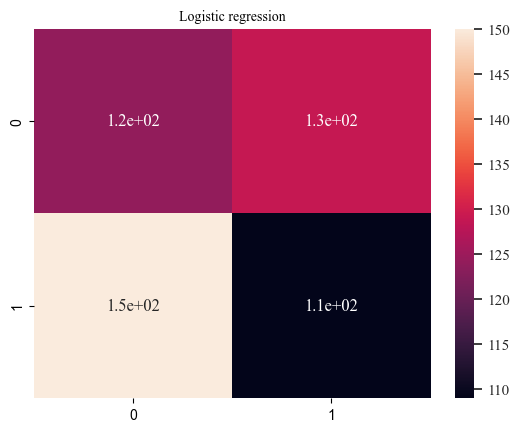

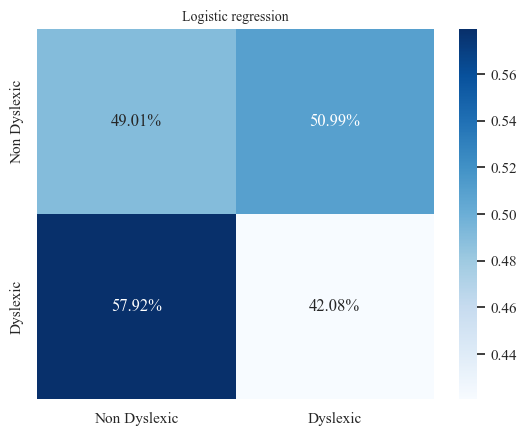

In [5]:
#Logistic regression
# # Split data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Standardize the data
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
log_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
log_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy (Logistic regression): {log_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy (Logistic regression): {log_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data (Logistic regression):")
print(classification_report(y_test, y_test_pred))

log_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
log_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data (Logistic Regression): {log_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Logistic regression', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(log_reg)_simple_[V].png", dpi=600)
plt.show() 
plt.title('Logistic regression', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# 1 = Dyslexic, 0 = Non_Dyslexic
sns.heatmap(cmn, annot=True, xticklabels=['Non Dyslexic','Dyslexic'], yticklabels=['Non Dyslexic','Dyslexic'], fmt='.2%', cmap='Blues')
#plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(log_reg)_percent_[V].png", dpi=600)
plt.show()

Training Accuracy (Support Vector Machine): 68.26%
Testing Accuracy (Support Vector Machine): 50.98%

Classification Report for Testing Data (Support Vector Machine):
              precision    recall  f1-score   support

           0       0.50      0.82      0.62       253
           1       0.54      0.21      0.30       259

    accuracy                           0.51       512
   macro avg       0.52      0.51      0.46       512
weighted avg       0.52      0.51      0.46       512


ROC-AUC score for Testing Data (Support Vector Machine): 0.51


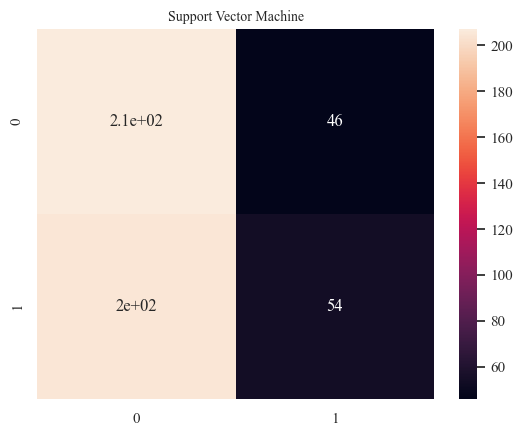

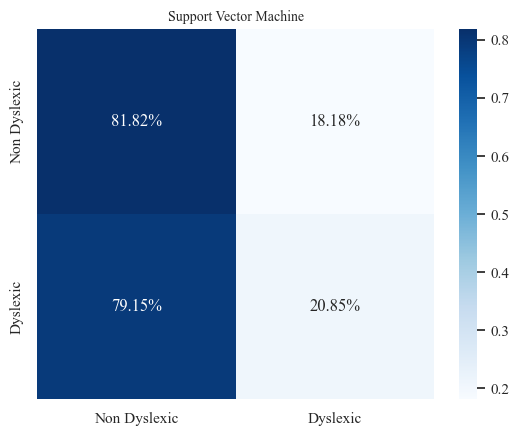

In [6]:
#Support Vector Machine
# # 1. Standardize the feature matrix
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # 2. Split the data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train the SVM model
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

# Make predictions on both training and testing sets
y_train_pred = svm_clf.predict(X_train)
y_test_pred = svm_clf.predict(X_test)

# Evaluate the model
svm_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
svm_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy (Support Vector Machine): {svm_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy (Support Vector Machine): {svm_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data (Support Vector Machine):")
print(classification_report(y_test, y_test_pred))

svm_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
svm_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data (Support Vector Machine): {svm_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Support Vector Machine', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(svm)_simple_[V].png", dpi=600)
plt.show() 
plt.title('Support Vector Machine', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.set(font="Times New Roman")
# 1 = Dyslexic, 0 = Non_Dyslexic
sns.heatmap(cmn, annot=True, xticklabels=['Non Dyslexic','Dyslexic'], yticklabels=['Non Dyslexic','Dyslexic'], fmt='.2%', cmap='Blues')
#plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(svm)_percent_[V].png", dpi=600)
plt.show()

Training Accuracy (k-nearest neighbors): 64.40%
Testing Accuracy (k-nearest neighbors): 48.63%

Classification Report for Testing Data (k-nearest neighbors):
              precision    recall  f1-score   support

           0       0.48      0.54      0.51       253
           1       0.49      0.43      0.46       259

    accuracy                           0.49       512
   macro avg       0.49      0.49      0.49       512
weighted avg       0.49      0.49      0.48       512


ROC-AUC score for Testing Data (k-nearest neighbors): 0.49


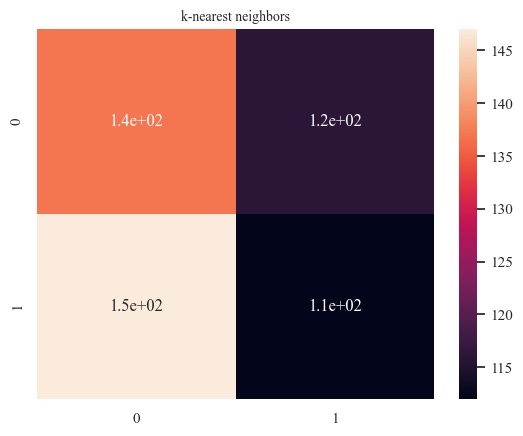

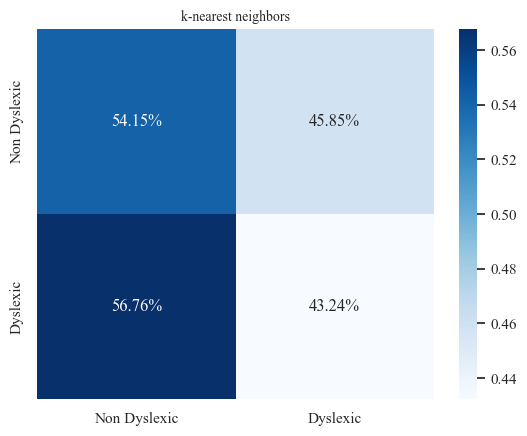

In [7]:
# k-nearest neighbors

# # Split data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Standardize the data
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calculate training and testing accuracy
knn_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
knn_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy (k-nearest neighbors): {knn_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy (k-nearest neighbors): {knn_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data (k-nearest neighbors):")
print(classification_report(y_test, y_test_pred))

knn_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
knn_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data (k-nearest neighbors): {knn_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('k-nearest neighbors', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(KNN)_simple_[V].png", dpi=600)
plt.show() 
plt.title('k-nearest neighbors', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.set(font="Times New Roman")
# 1 = Dyslexic, 0 = Non_Dyslexic
sns.heatmap(cmn, annot=True, xticklabels=['Non Dyslexic','Dyslexic'], yticklabels=['Non Dyslexic','Dyslexic'], fmt='.2%', cmap='Blues')
#plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(KNN)_percent_[V].png", dpi=600)
plt.show()

In [8]:
# print("Total Dataset:- ",X.shape)
# print("Total Labels:- ",y.shape)

# # Standardize the data
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

# # Split data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
# print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)
# #print(X_train_scaled.shape[1])


D:\Aanaconda3\envs\env_sih\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1024)                │       9,038,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,639,681 (36.77 MB)

 Trainable params: 9,639,681 (36.77 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.5204 - loss: 0.7381
Epoch 2/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.5636 - loss: 0.7585
Epoch 3/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.6448 - loss: 0.6364
Epoch 4/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.7326 - loss: 0.5164
Epoch 5/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.7983 - loss: 0.4315
Epoch 6/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.8572 - loss: 0.3185
Epoch 7/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.8689 - loss: 0.2976
Epoch 8/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.8846 - loss: 0.3125
Epoch 9/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.9011 - loss: 0.2289
Epoch 10/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.9302 - loss: 0.1961
Epoch 11/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.9341 - loss: 0.1440
Epoch 12/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy:

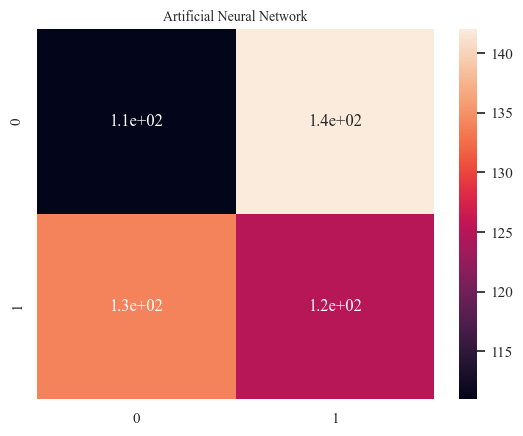

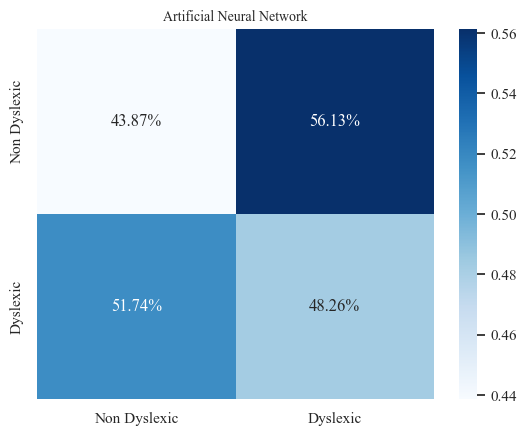

In [9]:
# Artificial Neural Network
input_shape = (X_train_scaled.shape[1],)
# set random seed for reproducibility
keras.utils.set_random_seed(42)
# define the model architecture
model = Sequential()
#model.add(Dense(4056, activation='relu', input_shape=input_shape))
#model.add(Dropout(0.5))
#model.add(Dense(2048, activation='relu', input_shape=input_shape))
#model.add(Dropout(0.5))
model.add(Dense(1024, activation='relu', input_shape=input_shape))
model.add(Dropout(0.5))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# print the model summary
model.summary()
# train the model
model.fit(X_train_scaled, y_train, batch_size=64, epochs=25)

y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.where(y_train_pred > 0.50, 1, 0)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred > 0.50, 1, 0)
# Calculate training and testing accuracy
# display(y_test_pred[:10])
# display(y_test[:10])
# Calculate training and testing accuracy
ann_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
ann_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy (Artificial Neural Network): {ann_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy (Artificial Neural Network): {ann_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data (Artificial Neural Network):")
print(classification_report(y_test, y_test_pred))

ann_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
ann_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data (Artificial Neural Network): {ann_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Artificial Neural Network', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(ANN)_simple_[V].png", dpi=600)
plt.show() 
plt.title('Artificial Neural Network', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.set(font="Times New Roman")
# 1 = Dyslexic, 0 = Non_Dyslexic
sns.heatmap(cmn, annot=True, xticklabels=['Non Dyslexic','Dyslexic'], yticklabels=['Non Dyslexic','Dyslexic'], fmt='.2%', cmap='Blues')
#plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(ANN)_percent_[V].png", dpi=600)
plt.show()

Training Accuracy (Random Forest): 100.00%
Testing Accuracy (Random Forest): 55.47%

Classification Report for Testing Data (Random Forest):
              precision    recall  f1-score   support

           0       0.55      0.57      0.56       253
           1       0.56      0.54      0.55       259

    accuracy                           0.55       512
   macro avg       0.55      0.55      0.55       512
weighted avg       0.56      0.55      0.55       512


ROC-AUC score for Testing Data (Random Forest): 0.55


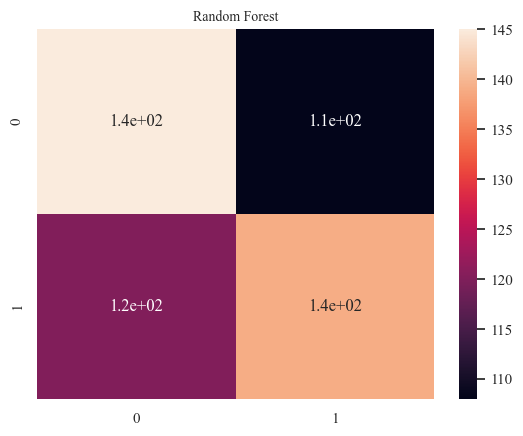

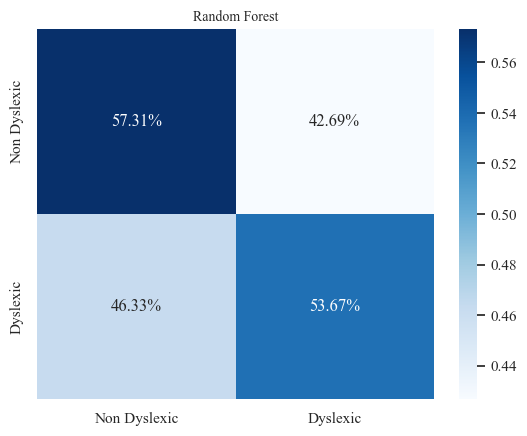

In [10]:
# Random Forest Model

# Instantiate the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42) #n_estimators can be adjusted
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
rf_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
rf_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy (Random Forest): {rf_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy (Random Forest): {rf_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data (Random Forest):")
print(classification_report(y_test, y_test_pred))

rf_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
rf_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data (Random Forest): {rf_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Random Forest', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(Rand_Frst)_simple_[V].png", dpi=600)
plt.show() 
plt.title('Random Forest', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# 1 = Dyslexic, 0 = Non_Dyslexic
sns.heatmap(cmn, annot=True, xticklabels=['Non Dyslexic','Dyslexic'], yticklabels=['Non Dyslexic','Dyslexic'], fmt='.2%', cmap='Blues')
#plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(Rand_Frst)_percent_[V].png", dpi=600)
plt.show()

Training Accuracy (XGBoost): 97.51%
Testing Accuracy (XGBoost): 56.64%

Classification Report for Testing Data (XGBoost):
              precision    recall  f1-score   support

           0       0.56      0.59      0.57       253
           1       0.58      0.54      0.56       259

    accuracy                           0.57       512
   macro avg       0.57      0.57      0.57       512
weighted avg       0.57      0.57      0.57       512


ROC-AUC score for Testing Data (XGBoost): 0.57


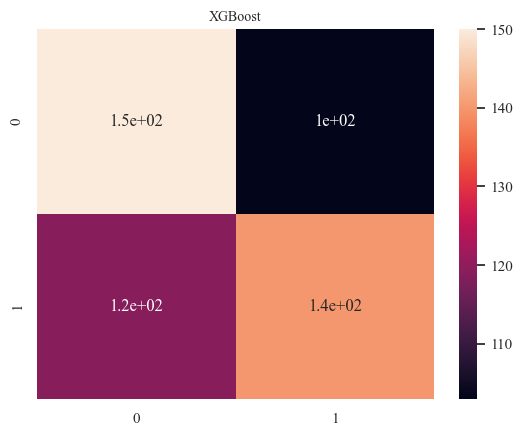

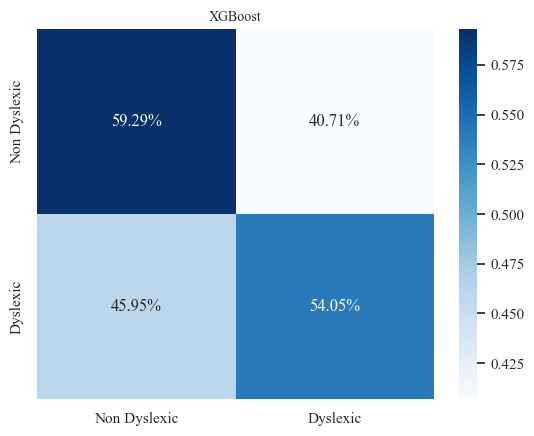

In [11]:
# XGBoost (Extreme Gradient Boosting) Model

# Initialize the XGBoost classifier
clf = xgb.XGBClassifier(
    objective='binary:logistic', # Specify binary classification
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
xgb_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
xgb_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy (XGBoost): {xgb_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy (XGBoost): {xgb_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data (XGBoost):")
print(classification_report(y_test, y_test_pred))

xgb_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
xgb_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data (XGBoost): {xgb_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('XGBoost', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(XGBst)_simple_[V].png", dpi=600)
plt.show() 
plt.title('XGBoost', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# 1 = Dyslexic, 0 = Non_Dyslexic
sns.heatmap(cmn, annot=True, xticklabels=['Non Dyslexic','Dyslexic'], yticklabels=['Non Dyslexic','Dyslexic'], fmt='.2%', cmap='Blues')
#plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(XGBst)_percent_[V].png", dpi=600)
plt.show()

#### <b> Display results in dataframe tabular format (Comparison of all the models)</b>

In [12]:
mean_all=[]
mean_all.append([round(log_mean_prf_All_ROIs[0][0],2),round(log_mean_prf_All_ROIs[1][0],2),round(log_mean_prf_All_ROIs[2][0],2),round(log_mean_test_accuracy_All_ROIs,2),round(log_mean_roc_All_ROIs,2)])
mean_all.append([round(log_mean_prf_All_ROIs[0][1],2),round(log_mean_prf_All_ROIs[1][1],2),round(log_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(svm_mean_prf_All_ROIs[0][0],2),round(svm_mean_prf_All_ROIs[1][0],2),round(svm_mean_prf_All_ROIs[2][0],2),round(svm_mean_test_accuracy_All_ROIs,2),round(svm_mean_roc_All_ROIs,2)])
mean_all.append([round(svm_mean_prf_All_ROIs[0][1],2),round(svm_mean_prf_All_ROIs[1][1],2),round(svm_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(knn_mean_prf_All_ROIs[0][0],2),round(knn_mean_prf_All_ROIs[1][0],2),round(knn_mean_prf_All_ROIs[2][0],2),round(knn_mean_test_accuracy_All_ROIs,2),round(knn_mean_roc_All_ROIs,2)])
mean_all.append([round(knn_mean_prf_All_ROIs[0][1],2),round(knn_mean_prf_All_ROIs[1][1],2),round(knn_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(ann_mean_prf_All_ROIs[0][0],2),round(ann_mean_prf_All_ROIs[1][0],2),round(ann_mean_prf_All_ROIs[2][0],2),round(ann_mean_test_accuracy_All_ROIs,2),round(ann_mean_roc_All_ROIs,2)])
mean_all.append([round(ann_mean_prf_All_ROIs[0][1],2),round(ann_mean_prf_All_ROIs[1][1],2),round(ann_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(rf_mean_prf_All_ROIs[0][0],2),round(rf_mean_prf_All_ROIs[1][0],2),round(rf_mean_prf_All_ROIs[2][0],2),round(rf_mean_test_accuracy_All_ROIs,2),round(rf_mean_roc_All_ROIs,2)])
mean_all.append([round(rf_mean_prf_All_ROIs[0][1],2),round(rf_mean_prf_All_ROIs[1][1],2),round(rf_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(xgb_mean_prf_All_ROIs[0][0],2),round(xgb_mean_prf_All_ROIs[1][0],2),round(xgb_mean_prf_All_ROIs[2][0],2),round(xgb_mean_test_accuracy_All_ROIs,2),round(xgb_mean_roc_All_ROIs,2)])
mean_all.append([round(xgb_mean_prf_All_ROIs[0][1],2),round(xgb_mean_prf_All_ROIs[1][1],2),round(xgb_mean_prf_All_ROIs[2][1],2),'',''])

df3 = pd.DataFrame(mean_all,
                   pd.MultiIndex.from_product([['Logistic Regression', 'Support Vector Machine','k-nearest neighbors','Artificial Neural Networks','Random Forest','XGBoost'], ['Non-Dyslexic', 'Dyslexic']]),
                   columns=['Precision','Recall','f1-score','Accuracy','roc_auc'])
df3.style\
.set_caption("Comparison Table (Experiment 1)")\
.set_table_styles([{'selector': 'table','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee"),("text-align", "center")]}], [{'selector': 'tr','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee"),("text-align", "center")]}])
display(df3)
df3.to_excel('../../Figure_Output/9-All_ROIs/Output_Mean/Table_Exp_1_[V].xlsx', engine='openpyxl')


Precision  Recall  f1-score Accuracy  \
Logistic Regression        Non-Dyslexic       0.45    0.49      0.47     0.46   
                           Dyslexic           0.46    0.42      0.44            
Support Vector Machine     Non-Dyslexic       0.50    0.82      0.62     0.51   
                           Dyslexic           0.54    0.21      0.30            
k-nearest neighbors        Non-Dyslexic       0.48    0.54      0.51     0.49   
                           Dyslexic           0.49    0.43      0.46            
Artificial Neural Networks Non-Dyslexic       0.45    0.44      0.45     0.46   
                           Dyslexic           0.47    0.48      0.48            
Random Forest              Non-Dyslexic       0.55    0.57      0.56     0.55   
                           Dyslexic           0.56    0.54      0.55            
XGBoost                    Non-Dyslexic       0.56    0.59      0.57     0.57   
                           Dyslexic           0.58    0.54      0.56            

                                        roc_auc  
Logistic Regression        Non-Dyslexic    0.46  
                           Dyslexic              
Support Vector Machine     Non-Dyslexic    0.51  
                           Dyslexic              
k-nearest neighbors        Non-Dyslexic    0.49  
                           Dyslexic              
Artificial Neural Networks Non-Dyslexic    0.46  
                           Dyslexic              
Random Forest              Non-Dyslexic    0.55  
                           Dyslexic              
XGBoost                    Non-Dyslexic    0.57  
                           Dyslexic

## Combining all the ROIs into a single dataset <i><b>(HORIZONTALLY)</b></i> to perform the experiments.
<b>Row=80+80=160; Column=67687(All the Columns of all the ROIs)</b>

In [13]:
control_m_d=np.concatenate((control_mean_data1, control_mean_data2,control_mean_data3, control_mean_data4,control_mean_data5, control_mean_data6,control_mean_data7, control_mean_data8,control_mean_data9, control_mean_data10,control_mean_data11, control_mean_data12,control_mean_data13, control_mean_data14,control_mean_data15, control_mean_data16), axis=1)
non_dyslexic_m_d=np.concatenate((non_dyslexic_mean_data1, non_dyslexic_mean_data2,non_dyslexic_mean_data3, non_dyslexic_mean_data4,non_dyslexic_mean_data5, non_dyslexic_mean_data6,non_dyslexic_mean_data7, non_dyslexic_mean_data8,non_dyslexic_mean_data9, non_dyslexic_mean_data10,non_dyslexic_mean_data11, non_dyslexic_mean_data12,non_dyslexic_mean_data13, non_dyslexic_mean_data14,non_dyslexic_mean_data15, non_dyslexic_mean_data16), axis=1)
print(len(control_m_d))
print(len(non_dyslexic_m_d))
print(control_m_d[0].shape)
print(non_dyslexic_m_d[0].shape)

# Combine the aggregated data from both groups
ll1=len(control_m_d)
ll2=len(non_dyslexic_m_d)
X = np.vstack([control_m_d ,non_dyslexic_m_d])  # Shape: (n_samples, n_voxels)
y = np.array([1] * ll1 + [0] * ll2)  # Binary labels
print(X.shape)
print(y.shape)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)

80
80
(67687,)
(67687,)
(160, 67687)
(160,)
Total Training set:-  Dataset:- (128, 67687) Label:- (128,)
Total Testing set:-  Dataset:- (32, 67687) Label:- (32,)


Training Accuracy (Logistic regression): 100.00%
Testing Accuracy (Logistic regression): 50.00%

Classification Report for Testing Data (Logistic regression):
              precision    recall  f1-score   support

           0       0.50      0.12      0.20        16
           1       0.50      0.88      0.64        16

    accuracy                           0.50        32
   macro avg       0.50      0.50      0.42        32
weighted avg       0.50      0.50      0.42        32


ROC-AUC score for Testing Data (Logistic Regression): 0.50


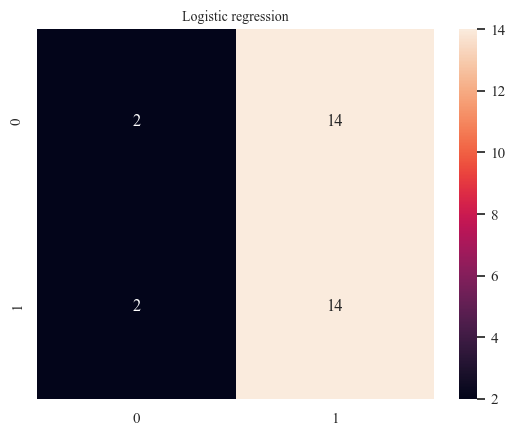

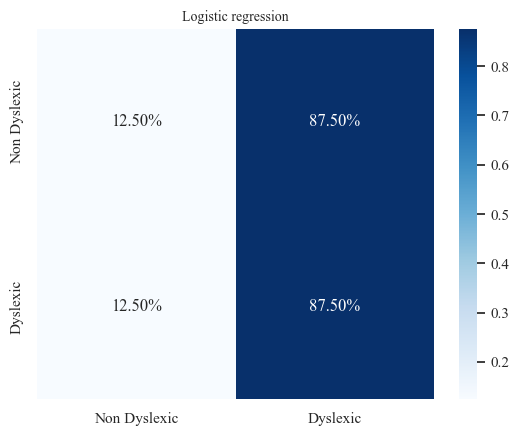

In [14]:
#Logistic regression

# # Split data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Standardize the data
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
log_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
log_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy (Logistic regression): {log_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy (Logistic regression): {log_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data (Logistic regression):")
print(classification_report(y_test, y_test_pred))

log_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)
# print(f"Precision 0:- {log_mean_prf_All_ROIs[0][0]:.2f}, Precision 1:- {log_mean_prf_All_ROIs[0][1]:.2f}")
# print(f"Recall 0:- {log_mean_prf_All_ROIs[1][0]:.2f}, Recall 1:- {log_mean_prf_All_ROIs[1][1]:.2f}")

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
log_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data (Logistic Regression): {log_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Logistic regression', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(log_reg)_simple_[H].png", dpi=600)
plt.show() 
plt.title('Logistic regression', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# 1 = Dyslexic, 0 = Non_Dyslexic
sns.heatmap(cmn, annot=True, xticklabels=['Non Dyslexic','Dyslexic'], yticklabels=['Non Dyslexic','Dyslexic'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(log_reg)_percent_[H].png", dpi=600)
plt.show()

Training Accuracy (Support Vector Machine): 73.44%
Testing Accuracy (Support Vector Machine): 56.25%

Classification Report for Testing Data (Support Vector Machine):
              precision    recall  f1-score   support

           0       0.55      0.75      0.63        16
           1       0.60      0.38      0.46        16

    accuracy                           0.56        32
   macro avg       0.57      0.56      0.55        32
weighted avg       0.57      0.56      0.55        32


ROC-AUC score for Testing Data (Support Vector Machine): 0.56


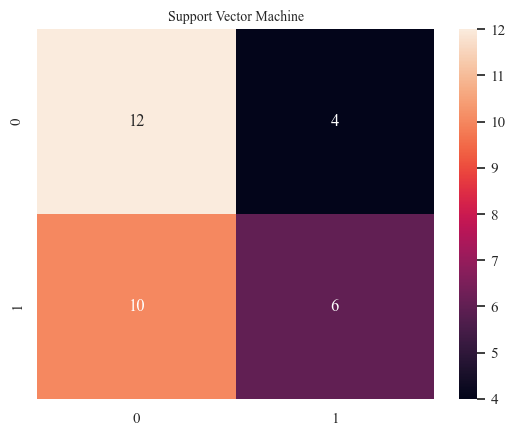

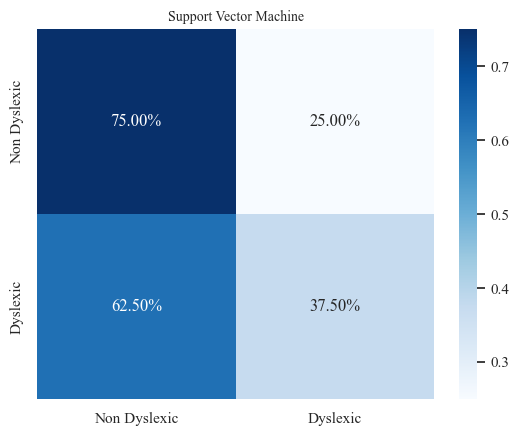

In [15]:
#Support Vector Machine

# # 1. Standardize the feature matrix
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # 2. Split the data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train the SVM model
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

# Make predictions on both training and testing sets
y_train_pred = svm_clf.predict(X_train)
y_test_pred = svm_clf.predict(X_test)

# Evaluate the model
svm_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
svm_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy (Support Vector Machine): {svm_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy (Support Vector Machine): {svm_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data (Support Vector Machine):")
print(classification_report(y_test, y_test_pred))

svm_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
svm_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data (Support Vector Machine): {svm_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Support Vector Machine', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(svm)_simple_[H].png", dpi=600)
plt.show() 
plt.title('Support Vector Machine', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.set(font="Times New Roman")
# 1 = Dyslexic, 0 = Non_Dyslexic
sns.heatmap(cmn, annot=True, xticklabels=['Non Dyslexic','Dyslexic'], yticklabels=['Non Dyslexic','Dyslexic'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(svm)_percent_[H].png", dpi=600)
plt.show()

Training Accuracy (k-nearest neighbors): 50.00%
Testing Accuracy (k-nearest neighbors): 50.00%

Classification Report for Testing Data (k-nearest neighbors):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        16
           1       0.50      1.00      0.67        16

    accuracy                           0.50        32
   macro avg       0.25      0.50      0.33        32
weighted avg       0.25      0.50      0.33        32


ROC-AUC score for Testing Data (k-nearest neighbors): 0.50


D:\Aanaconda3\envs\env_sih\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Aanaconda3\envs\env_sih\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Aanaconda3\envs\env_sih\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Aanaconda3\envs\env_sih\lib\sit

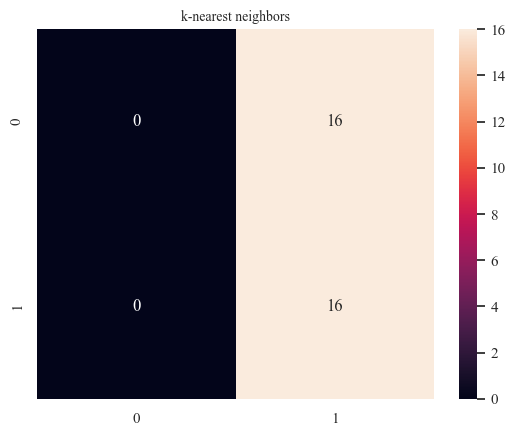

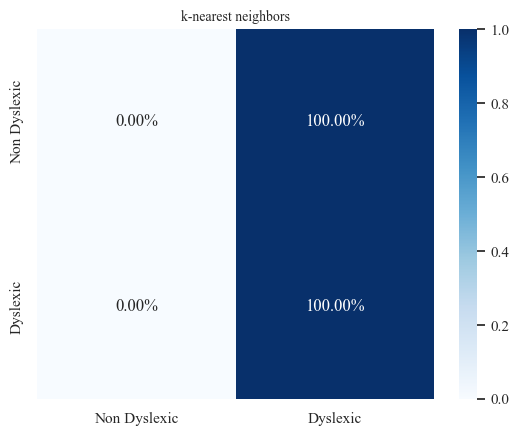

In [16]:
# k-nearest neighbors

# # Split data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Standardize the data
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calculate training and testing accuracy
knn_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
knn_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy (k-nearest neighbors): {knn_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy (k-nearest neighbors): {knn_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data (k-nearest neighbors):")
print(classification_report(y_test, y_test_pred))

knn_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
knn_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data (k-nearest neighbors): {knn_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('k-nearest neighbors', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(KNN)_simple_[H].png", dpi=600)
plt.show() 
plt.title('k-nearest neighbors', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.set(font="Times New Roman")
# 1 = Dyslexic, 0 = Non_Dyslexic
sns.heatmap(cmn, annot=True, xticklabels=['Non Dyslexic','Dyslexic'], yticklabels=['Non Dyslexic','Dyslexic'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(KNN)_percent_[H].png", dpi=600)
plt.show()

D:\Aanaconda3\envs\env_sih\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 1024)                │      69,312,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 69,913,345 (266.70 MB)

 Trainable params: 69,913,345 (266.70 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 596ms/step - accuracy: 0.5104 - loss: 0.7978
Epoch 2/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step - accuracy: 0.6979 - loss: 0.8891
Epoch 3/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step - accuracy: 0.7500 - loss: 1.3685
Epoch 4/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step - accuracy: 0.8333 - loss: 0.4946
Epoch 5/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step - accuracy: 0.8073 - loss: 0.4209
Epoch 6/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step - accuracy: 0.9271 - loss: 0.1939
Epoch 7/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 564ms/step - accuracy: 0.9271 - loss: 0.1647
Epoch 8/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 576ms/step - accuracy: 0.8698 - loss: 0.8119
Epoch 9/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step - accuracy: 0.9688 - loss: 0.0899
Epoch 10/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 566ms/step - accuracy: 0.9323 - loss: 0.1956
Epoch 11/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 569ms/step - accuracy: 0.9688 - loss: 0.0784
Epoch 12/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step - accuracy: 0.9896 - lo

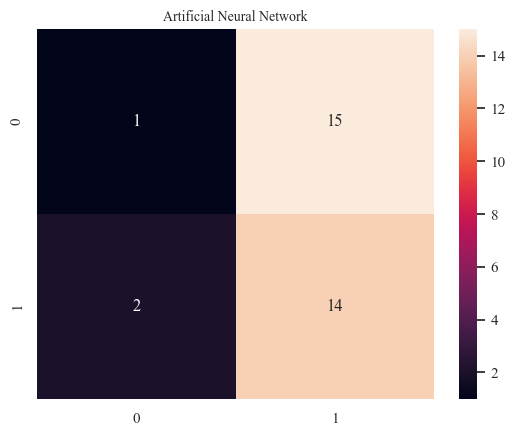

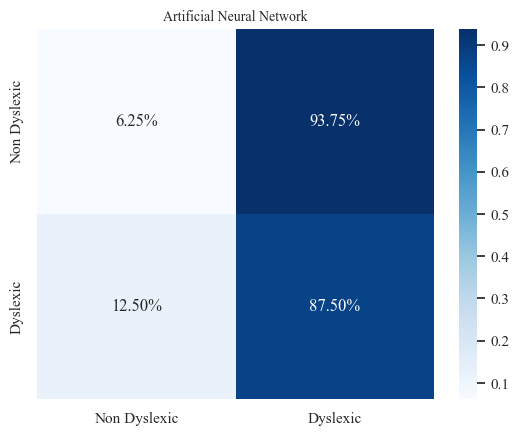

In [17]:
# Artificial Neural Network
input_shape = (X_train_scaled.shape[1],)
# set random seed for reproducibility
keras.utils.set_random_seed(42)
# define the model architecture
model = Sequential()
#model.add(Dense(4056, activation='relu', input_shape=input_shape))
#model.add(Dropout(0.5))
#model.add(Dense(2048, activation='relu', input_shape=input_shape))
#model.add(Dropout(0.5))
model.add(Dense(1024, activation='relu', input_shape=input_shape))
model.add(Dropout(0.5))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# print the model summary
model.summary()
# train the model
model.fit(X_train_scaled, y_train, batch_size=64, epochs=25)

y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.where(y_train_pred > 0.50, 1, 0)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred > 0.50, 1, 0)
# Calculate training and testing accuracy
# display(y_test_pred[:10])
# display(y_test[:10])
# Calculate training and testing accuracy
ann_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
ann_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy (Artificial Neural Network): {ann_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy (Artificial Neural Network): {ann_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data (Artificial Neural Network):")
print(classification_report(y_test, y_test_pred))

ann_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
ann_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data (Artificial Neural Network): {ann_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Artificial Neural Network', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(ANN)_simple_[H].png", dpi=600)
plt.show() 
plt.title('Artificial Neural Network', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.set(font="Times New Roman")
# 1 = Dyslexic, 0 = Non_Dyslexic
sns.heatmap(cmn, annot=True, xticklabels=['Non Dyslexic','Dyslexic'], yticklabels=['Non Dyslexic','Dyslexic'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(ANN)_percent_[H].png", dpi=600)
plt.show()

Training Accuracy (Random Forest): 100.00%
Testing Accuracy (Random Forest): 68.75%

Classification Report for Testing Data (Random Forest):
              precision    recall  f1-score   support

           0       0.67      0.75      0.71        16
           1       0.71      0.62      0.67        16

    accuracy                           0.69        32
   macro avg       0.69      0.69      0.69        32
weighted avg       0.69      0.69      0.69        32


ROC-AUC score for Testing Data (Random Forest): 0.69


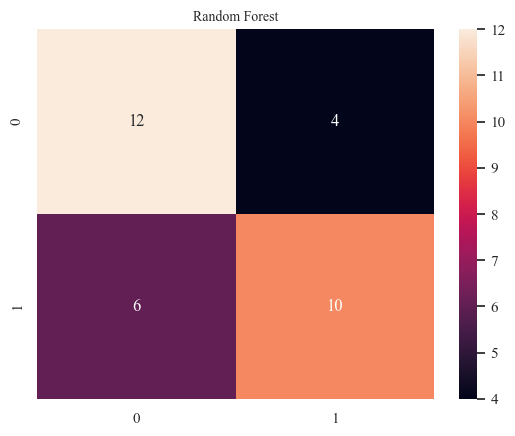

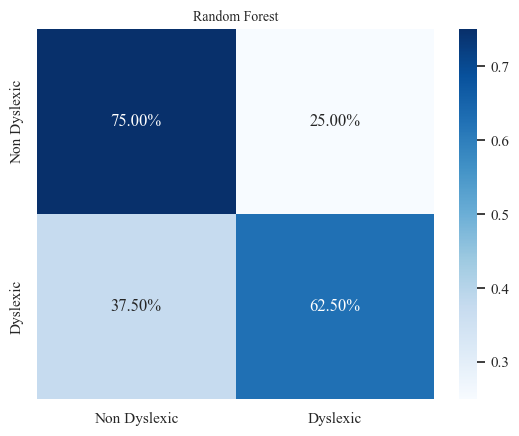

In [18]:
# Random Forest Model

# Instantiate the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42) #n_estimators can be adjusted
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
rf_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
rf_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy (Random Forest): {rf_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy (Random Forest): {rf_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data (Random Forest):")
print(classification_report(y_test, y_test_pred))

rf_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
rf_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data (Random Forest): {rf_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('Random Forest', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(Rand_Frst)_simple_[H].png", dpi=600)
plt.show() 
plt.title('Random Forest', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# 1 = Dyslexic, 0 = Non_Dyslexic
sns.heatmap(cmn, annot=True, xticklabels=['Non Dyslexic','Dyslexic'], yticklabels=['Non Dyslexic','Dyslexic'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(Rand_Frst)_percent_[H].png", dpi=600)
plt.show()

Training Accuracy (XGBoost): 100.00%
Testing Accuracy (XGBoost): 53.12%

Classification Report for Testing Data (XGBoost):
              precision    recall  f1-score   support

           0       0.53      0.50      0.52        16
           1       0.53      0.56      0.55        16

    accuracy                           0.53        32
   macro avg       0.53      0.53      0.53        32
weighted avg       0.53      0.53      0.53        32


ROC-AUC score for Testing Data (XGBoost): 0.53


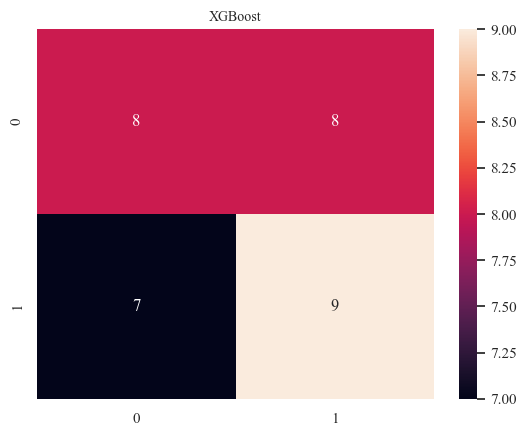

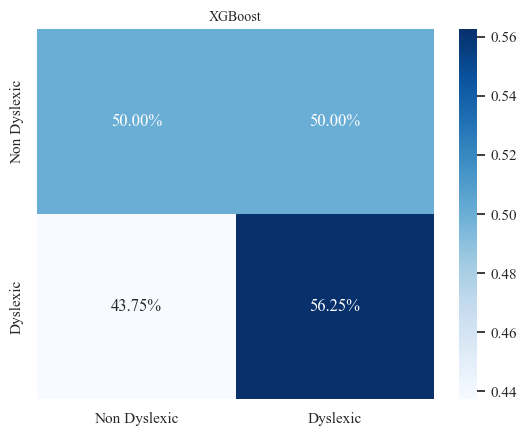

In [19]:
# XGBoost (Extreme Gradient Boosting) Model

# Initialize the XGBoost classifier
clf = xgb.XGBClassifier(
    objective='binary:logistic', # Specify binary classification
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
xgb_mean_train_accuracy_All_ROIs = accuracy_score(y_train, y_train_pred)
xgb_mean_test_accuracy_All_ROIs = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy (XGBoost): {xgb_mean_train_accuracy_All_ROIs * 100:.2f}%")
print(f"Testing Accuracy (XGBoost): {xgb_mean_test_accuracy_All_ROIs * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data (XGBoost):")
print(classification_report(y_test, y_test_pred))

xgb_mean_prf_All_ROIs=precision_recall_fscore_support(y_test, y_test_pred)

# Calculate ROC-AUC score
## A higher AUC-ROC score indicates better model performance. 
## An AUC-ROC of 1.0 represents a perfect model, while 0.5 indicates a model that is no better than random guessing. 
## AUC-ROC values typically range from 0 to 1. 
xgb_mean_roc_All_ROIs = roc_auc_score(y_test, y_test_pred)
print(f"\nROC-AUC score for Testing Data (XGBoost): {xgb_mean_roc_All_ROIs:.2f}")

cm = confusion_matrix(y_test, y_test_pred)
# print(cm)
plt.title('XGBoost', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(XGBst)_simple_[H].png", dpi=600)
plt.show() 
plt.title('XGBoost', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
# 1 = Dyslexic, 0 = Non_Dyslexic
sns.heatmap(cmn, annot=True, xticklabels=['Non Dyslexic','Dyslexic'], yticklabels=['Non Dyslexic','Dyslexic'], fmt='.2%', cmap='Blues')
plt.savefig("../../Figure_Output/9-All_ROIs/Output_Mean/Exp_1(XGBst)_percent_[H].png", dpi=600)
plt.show()

In [20]:
mean_all=[]
mean_all.append([round(log_mean_prf_All_ROIs[0][0],2),round(log_mean_prf_All_ROIs[1][0],2),round(log_mean_prf_All_ROIs[2][0],2),round(log_mean_test_accuracy_All_ROIs,2),round(log_mean_roc_All_ROIs,2)])
mean_all.append([round(log_mean_prf_All_ROIs[0][1],2),round(log_mean_prf_All_ROIs[1][1],2),round(log_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(svm_mean_prf_All_ROIs[0][0],2),round(svm_mean_prf_All_ROIs[1][0],2),round(svm_mean_prf_All_ROIs[2][0],2),round(svm_mean_test_accuracy_All_ROIs,2),round(svm_mean_roc_All_ROIs,2)])
mean_all.append([round(svm_mean_prf_All_ROIs[0][1],2),round(svm_mean_prf_All_ROIs[1][1],2),round(svm_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(knn_mean_prf_All_ROIs[0][0],2),round(knn_mean_prf_All_ROIs[1][0],2),round(knn_mean_prf_All_ROIs[2][0],2),round(knn_mean_test_accuracy_All_ROIs,2),round(knn_mean_roc_All_ROIs,2)])
mean_all.append([round(knn_mean_prf_All_ROIs[0][1],2),round(knn_mean_prf_All_ROIs[1][1],2),round(knn_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(ann_mean_prf_All_ROIs[0][0],2),round(ann_mean_prf_All_ROIs[1][0],2),round(ann_mean_prf_All_ROIs[2][0],2),round(ann_mean_test_accuracy_All_ROIs,2),round(ann_mean_roc_All_ROIs,2)])
mean_all.append([round(ann_mean_prf_All_ROIs[0][1],2),round(ann_mean_prf_All_ROIs[1][1],2),round(ann_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(rf_mean_prf_All_ROIs[0][0],2),round(rf_mean_prf_All_ROIs[1][0],2),round(rf_mean_prf_All_ROIs[2][0],2),round(rf_mean_test_accuracy_All_ROIs,2),round(rf_mean_roc_All_ROIs,2)])
mean_all.append([round(rf_mean_prf_All_ROIs[0][1],2),round(rf_mean_prf_All_ROIs[1][1],2),round(rf_mean_prf_All_ROIs[2][1],2),'',''])
mean_all.append([round(xgb_mean_prf_All_ROIs[0][0],2),round(xgb_mean_prf_All_ROIs[1][0],2),round(xgb_mean_prf_All_ROIs[2][0],2),round(xgb_mean_test_accuracy_All_ROIs,2),round(xgb_mean_roc_All_ROIs,2)])
mean_all.append([round(xgb_mean_prf_All_ROIs[0][1],2),round(xgb_mean_prf_All_ROIs[1][1],2),round(xgb_mean_prf_All_ROIs[2][1],2),'',''])

df3 = pd.DataFrame(mean_all,
                   pd.MultiIndex.from_product([['Logistic Regression', 'Support Vector Machine','k-nearest neighbors','Artificial Neural Networks','Random Forest','XGBoost'], ['Non-Dyslexic', 'Dyslexic']]),
                   columns=['Precision','Recall','f1-score','Accuracy','roc_auc'])
df3.style\
.set_caption("Comparison Table (Experiment 1)")\
.set_table_styles([{'selector': 'table','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee"),("text-align", "center")]}], [{'selector': 'tr','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee"),("text-align", "center")]}])
display(df3)
df3.to_excel('../../Figure_Output/9-All_ROIs/Output_Mean/Table_Exp_1_[H].xlsx', engine='openpyxl')


Precision  Recall  f1-score Accuracy  \
Logistic Regression        Non-Dyslexic       0.50    0.12      0.20      0.5   
                           Dyslexic           0.50    0.88      0.64            
Support Vector Machine     Non-Dyslexic       0.55    0.75      0.63     0.56   
                           Dyslexic           0.60    0.38      0.46            
k-nearest neighbors        Non-Dyslexic       0.00    0.00      0.00      0.5   
                           Dyslexic           0.50    1.00      0.67            
Artificial Neural Networks Non-Dyslexic       0.33    0.06      0.11     0.47   
                           Dyslexic           0.48    0.88      0.62            
Random Forest              Non-Dyslexic       0.67    0.75      0.71     0.69   
                           Dyslexic           0.71    0.62      0.67            
XGBoost                    Non-Dyslexic       0.53    0.50      0.52     0.53   
                           Dyslexic           0.53    0.56      0.55            

                                        roc_auc  
Logistic Regression        Non-Dyslexic     0.5  
                           Dyslexic              
Support Vector Machine     Non-Dyslexic    0.56  
                           Dyslexic              
k-nearest neighbors        Non-Dyslexic     0.5  
                           Dyslexic              
Artificial Neural Networks Non-Dyslexic    0.47  
                           Dyslexic              
Random Forest              Non-Dyslexic    0.69  
                           Dyslexic              
XGBoost                    Non-Dyslexic    0.53  
                           Dyslexic